In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset for the local operator

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_24Hz_10Hz_trans'
x_len           = 200 # 40 * 5

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


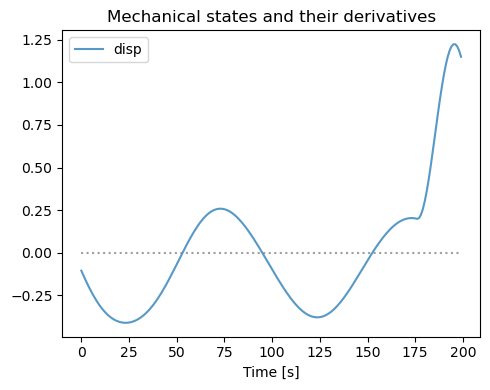

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize loaded data

data_i = 0
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='disp')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! load a trained global model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = torch.load('data/models/care_global.pt', weights_only=False)

print(model.timeseries_dyn.weight)

Parameter containing:
tensor([[-0.8778,  0.3808, -0.1603, -0.2009],
        [-1.0883, -0.2986,  0.0785, -0.7342],
        [ 0.5551, -0.0808,  0.8260, -0.1546],
        [ 0.0581, -0.6762,  0.2647,  0.5867]], requires_grad=True)


inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


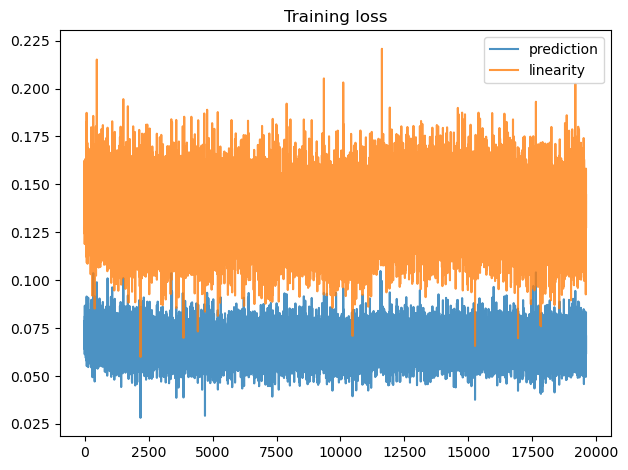

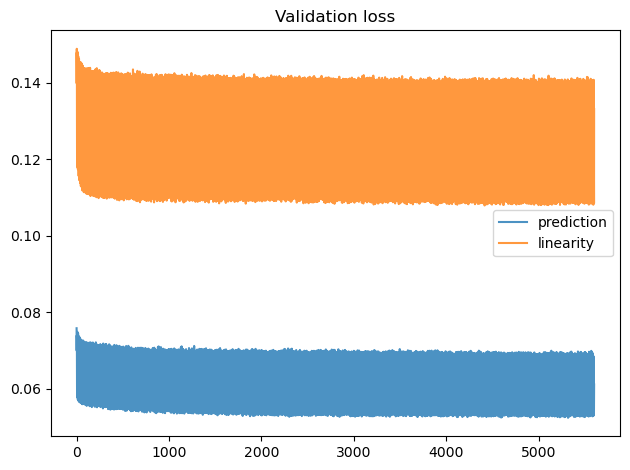

inf >> prediction loss in training is 6.677080e-02
inf >> linearity loss in training is 1.349169e-01


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the local Koopman operator

# --! we train the local operator now, so freeze the global one
utils.freeze_module(model.timeseries_dyn)
utils.freeze_module(model.fun_params_kern_enc)
utils.freeze_module(model.dec)
utils.unfreeze_module(model.funs_dyn_enc)
utils.unfreeze_module(model.funs_dyn)

alpha = 0.85

bat_sz = 128
 
# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_pred  = []
loss_train_lin   = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 7
epochs_n          = 100
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x, fixed_alpha=alpha)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred  = model(x, fixed_alpha=alpha)
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')

In [6]:
# --!--------------------------------------------------------------------------
# --! gather test statistics

with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        funs, funs_pred, timeseries_recon, timeseries_pred = model(x, fixed_alpha=alpha)
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_pred_mean = np.mean(loss_test_pred)
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}') # 5.031356e-03

inf >> prediction loss in test is 6.032255e-02


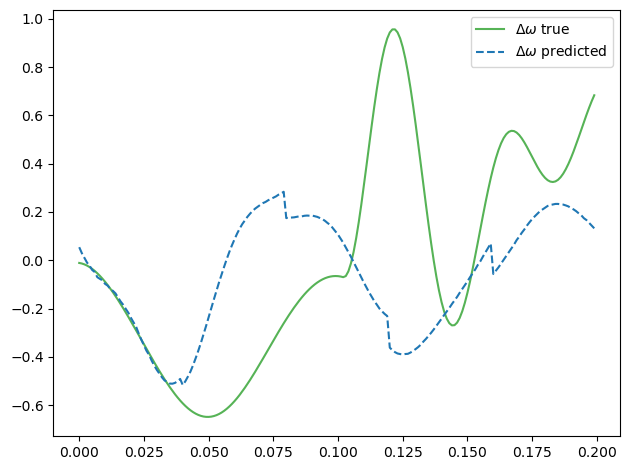

In [7]:
# --!--------------------------------------------------------------------------
# --! test individual results

with torch.no_grad():
    data_i  = 2
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    funs, funs_pred, timeseries_recon, timeseries_pred = model(timeseries, fixed_alpha=alpha)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

Parameter containing:
tensor([[-0.8778,  0.3808, -0.1603, -0.2009],
        [-1.0883, -0.2986,  0.0785, -0.7342],
        [ 0.5551, -0.0808,  0.8260, -0.1546],
        [ 0.0581, -0.6762,  0.2647,  0.5867]])


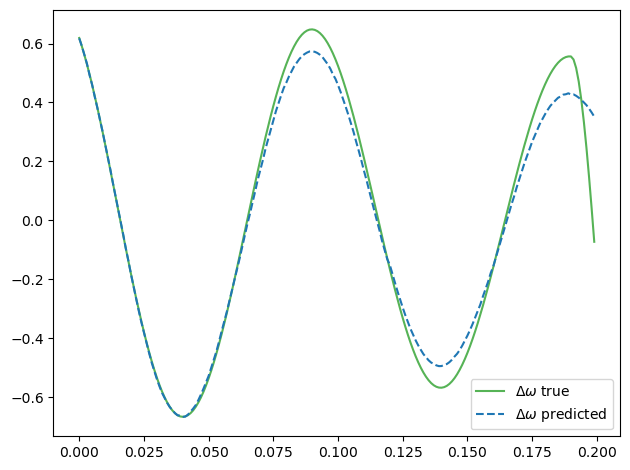

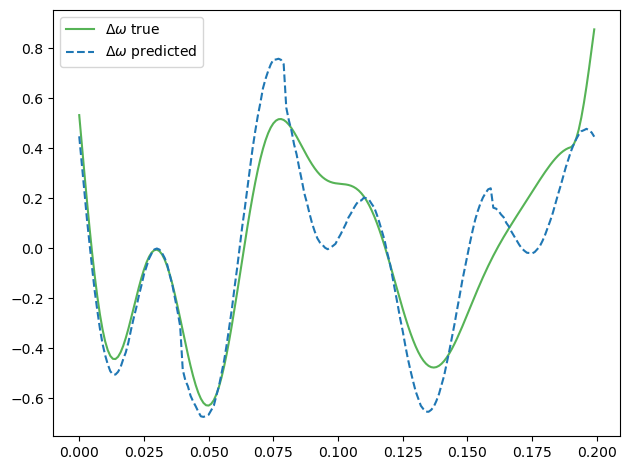

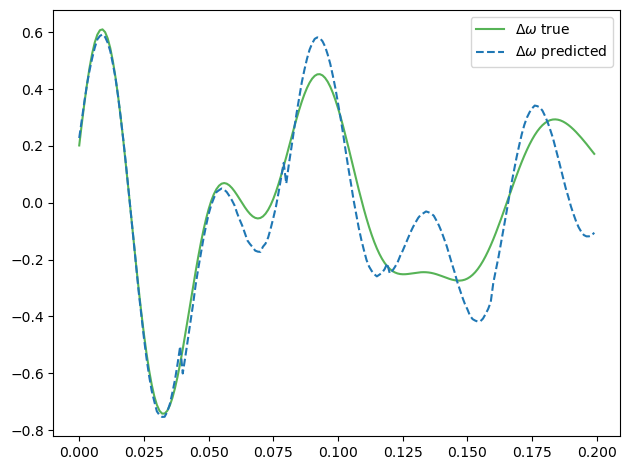

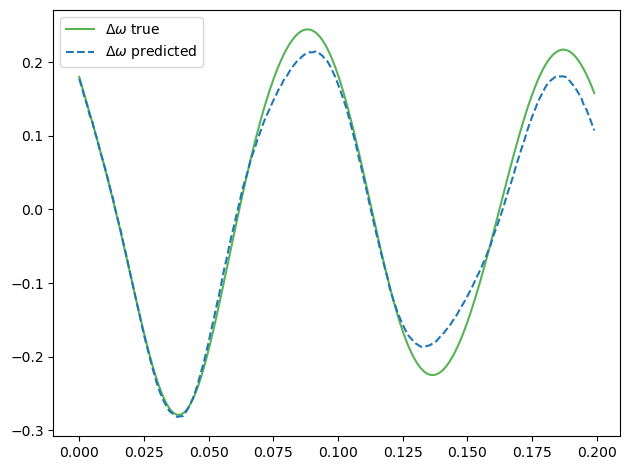

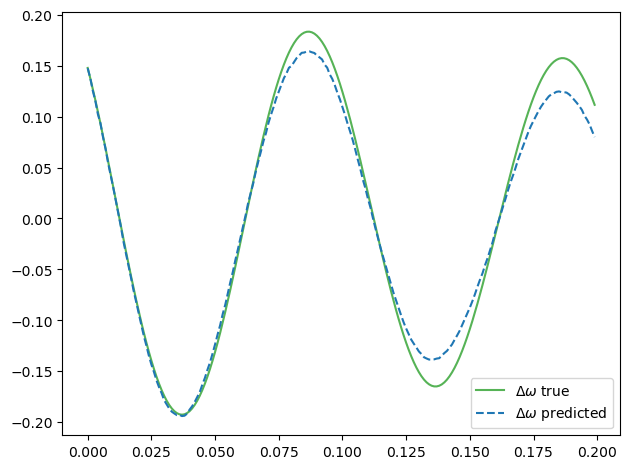

inf >> prediction loss in evaluation is 8.667191e-03


In [11]:
# --!--------------------------------------------------------------------------
# --! analyze attention on unseen transition time series

# --! ensure meaningful comparisons
seed = 5
torch.manual_seed(seed)

print(model.timeseries_dyn.weight)

def plot_attention_matrix(attn_matrix, function_labels=None, title="Attention Matrix over Basis Functions"):
    """
    Plots an attention matrix where rows = queries (functions asking "who to attend to?")
    and columns = keys (functions being attended to).
    
    Args:
        attn_matrix (torch.Tensor): shape [1, num_queries, num_keys]
        function_labels (list of str): Optional. Labels for the basis functions.
        title (str): Title of the plot.
    """
    # Remove batch dimension if present
    if attn_matrix.ndim == 3:
        attn_matrix = attn_matrix.squeeze(0)

    num_funcs = attn_matrix.size(0)
    
    if function_labels is None:
        function_labels = [f"g{i+1}" for i in range(num_funcs)]
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(attn_matrix.detach().numpy(), annot=True, cmap="viridis", 
                xticklabels=function_labels, yticklabels=function_labels, cbar=True,
                fmt=".2f")
    plt.xlabel("Keys (Attended Basis Functions)")
    plt.ylabel("Queries (Attending Basis Functions)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

loss_eval_pred    = []

fixed_alphas = [1.0, 0.85, 0.85, 1.0, 1.0]

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for datum, fixed_alpha in zip(data, fixed_alphas):
        datum = datum[:, :x_len, :1]
        outs = model(datum, fixed_alpha=fixed_alpha, adapt_alpha=False)

        #entropy = model._attention2entropy(outs[5])
        #alpha_from_entropy = model._entropy2alpha(entropy)

        #print(f'entropy: {entropy}')
        #print(f'alpha from entropy: {alpha_from_entropy}')

        #plot_attention_matrix(
            #outs[5],
            #function_labels=list(model.fun_params_n.keys()),
            #title='Local Attention - Test Waveform')

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_pred = torch.squeeze(outs[3], dim=0)

        # compute losses for metrics
        loss_eval_pred.append(torch.mean((timeseries - timeseries_pred)**2))

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep)

        plt.figure()
        plt.plot(t[:x_len], timeseries[:x_len, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t[:x_len], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()

    loss_eval_pred_mean = np.mean(loss_eval_pred)
    print(f'inf >> prediction loss in evaluation is {loss_eval_pred_mean:e}') # 0.5 : 4.265533e-03 -> 5.077887e-03